In [78]:
import pickle
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, SplineTransformer, PolynomialFeatures, QuantileTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, root_mean_squared_error
import pandas as pd
import mlflow
from mlflow.models import infer_signature
from mlxtend.feature_selection import SequentialFeatureSelector
import optuna

In [79]:
with open('../data/dataset.pkl', 'rb') as handle:
    df = pickle.load(handle)

In [80]:
df = df.rename(columns={'salary_in_usd': 'target'})
X = df.drop('target', axis=1)
y = df['target']

In [81]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [82]:
num_features = X.select_dtypes(include=['number']).columns.to_list()
print(num_features)
cat_features = X.select_dtypes(include=['category']).columns.to_list()
print(cat_features)

['work_year', 'remote_ratio']
['experience_level', 'employment_type', 'job_title', 'employee_residence', 'company_location', 'company_size']


# sklearn

In [83]:
X_train_sklearn = X_train.copy()

In [84]:
pf = PolynomialFeatures(degree=2)
pf.fit_transform(X_train_sklearn[['work_year', 'remote_ratio']])

array([[1.000000e+00, 2.022000e+03, 1.000000e+02, 4.088484e+06,
        2.022000e+05, 1.000000e+04],
       [1.000000e+00, 2.023000e+03, 0.000000e+00, 4.092529e+06,
        0.000000e+00, 0.000000e+00],
       [1.000000e+00, 2.023000e+03, 0.000000e+00, 4.092529e+06,
        0.000000e+00, 0.000000e+00],
       ...,
       [1.000000e+00, 2.023000e+03, 1.000000e+02, 4.092529e+06,
        2.023000e+05, 1.000000e+04],
       [1.000000e+00, 2.021000e+03, 5.000000e+01, 4.084441e+06,
        1.010500e+05, 2.500000e+03],
       [1.000000e+00, 2.022000e+03, 1.000000e+02, 4.088484e+06,
        2.022000e+05, 1.000000e+04]])

In [85]:
sp = SplineTransformer(n_knots=3, degree=3)
sp.fit_transform(X_train_sklearn[['work_year']])

array([[0.        , 0.04938272, 0.57407407, 0.37037037, 0.00617284],
       [0.        , 0.        , 0.16666667, 0.66666667, 0.16666667],
       [0.        , 0.        , 0.16666667, 0.66666667, 0.16666667],
       ...,
       [0.        , 0.        , 0.16666667, 0.66666667, 0.16666667],
       [0.00617284, 0.37037037, 0.57407407, 0.04938272, 0.        ],
       [0.        , 0.04938272, 0.57407407, 0.37037037, 0.00617284]])

In [86]:
qt = QuantileTransformer()

In [87]:
qt.fit_transform(X_train_sklearn[['work_year']])

array([[0.3048048 ],
       [1.        ],
       [1.        ],
       ...,
       [1.        ],
       [0.04954955],
       [0.3048048 ]])

Объединяем в ColumnTransformer и создаем Pipeline

In [88]:
pf = PolynomialFeatures(degree=2)
qt = QuantileTransformer()
sp = SplineTransformer(n_knots=3, degree=3)

In [89]:
# Значения преобразованных признаков нужно отскейлить, поэтому создаем pipeline из двух шагов - преобразование и скейлинг
pf_pipeline = Pipeline(steps=[
    ('poly', pf),
    ('scale', StandardScaler())
])

In [90]:
# это что-то страшное
# я не верю что это лучше базовой модели...
preprocessor_sklearn = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),  # преобразования для числовых признаков
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=99999999), cat_features), # преобразования для категориальных признаков
        ('quantile', qt, num_features),
        ('poly', pf_pipeline, ['work_year', 'remote_ratio']), # В преобразования добавляем созданный ранее pipeline
        ('spline', sp, ['work_year'])
    ],
    remainder='drop',
    ) # Удаляем столбцы, которые не затронуты преобразования

In [91]:
X_train_sklearn[['work_year', 'remote_ratio']] = X_train_sklearn[['work_year', 'remote_ratio']].astype('float64')

In [92]:
X_train_sklearn_raw = preprocessor_sklearn.fit_transform(X_train_sklearn)
X_train_sklearn = pd.DataFrame(X_train_sklearn_raw, columns=preprocessor_sklearn.get_feature_names_out())

In [93]:
with pd.option_context('display.max_rows', 5, 'display.max_columns', None):
    display (X_train_sklearn)

,num__work_year,num__remote_ratio,cat__experience_level,cat__employment_type,cat__job_title,cat__employee_residence,cat__company_location,cat__company_size,quantile__work_year,quantile__remote_ratio,poly__1,poly__work_year,poly__remote_ratio,poly__work_year^2,poly__work_year remote_ratio,poly__remote_ratio^2,spline__work_year_sp_0,spline__work_year_sp_1,spline__work_year_sp_2,spline__work_year_sp_3,spline__work_year_sp_4
0,-0.537526,1.104785,0.0,2.0,24.0,57.0,46.0,2.0,0.304805,1.000000,0.0,-0.537526,1.104785,-0.537739,1.104559,1.124608,0.000000,0.049383,0.574074,0.370370,0.006173
1,0.917538,-0.950578,3.0,2.0,46.0,57.0,46.0,1.0,1.000000,0.000000,0.0,0.917538,-0.950578,0.917668,-0.950563,-0.922395,0.000000,0.000000,0.166667,0.666667,0.166667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2797,-1.992590,0.077104,3.0,2.0,42.0,8.0,7.0,0.0,0.049550,0.537538,0.0,-1.992590,0.077104,-1.992426,0.076490,-0.410644,0.006173,0.370370,0.574074,0.049383,0.000000
2798,-0.537526,1.104785,3.0,2.0,32.0,57.0,46.0,1.0,0.304805,1.000000,0.0,-0.537526,1.104785,-0.537739,1.104559,1.124608,0.000000,0.049383,0.574074,0.370370,0.006173


Создаем пайплайн с препроцессингом и моделью

In [94]:
regressor = RandomForestRegressor()
pipeline_sklearn = Pipeline(steps=[
    ('transform', preprocessor_sklearn),
    ('model', regressor)
])

model_sklearn = pipeline_sklearn.fit(X_train, y_train)

In [95]:
model_sklearn

Pipeline(steps=[('transform',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['work_year',
                                                   'remote_ratio']),
                                                 ('cat',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=99999999),
                                                  ['experience_level',
                                                   'employment_type',
                                                   'job_title',
                                                   'employee_residence',
                                                   'company_location',
                                                   'company_size']),
                                                 ('quantile',
                                                  QuantileTransformer(),
                                                  ['work_year',
                                                   'remote_ratio']),
                                                 ('poly',
                                                  Pipeline(steps=[('poly',
                                                                   PolynomialFeatures()),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['work_year',
                                                   'remote_ratio']),
                                                 ('spline',
                                                  SplineTransformer(n_knots=3),
                                                  ['work_year'])])),
                ('model', RandomForestRegressor())])

In [96]:
predictions = pipeline_sklearn.predict(X_test)

metrics = {}
metrics["mae"] = mean_absolute_error(y_test, predictions)
metrics["mape"] = mean_absolute_percentage_error(y_test, predictions)
metrics["rmse"] = root_mean_squared_error(y_test, predictions)

metrics

{'mae': 36253.156762657505,
 'mape': 0.3239284893269982,
 'rmse': 49488.8515312538}

In [97]:
# Работаем с MLflow локально
TRACKING_SERVER_HOST = "127.0.0.1"
TRACKING_SERVER_PORT = 5000

registry_uri = f"http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}"
tracking_uri = f"http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}"

mlflow.set_tracking_uri(tracking_uri)
mlflow.set_registry_uri(registry_uri)
# название тестового эксперимента, запуска (run) внутри него, имени, под которым модель будет регистрироваться
EXPERIMENT_NAME = "estate_project"
RUN_NAME = 'fe_sklearn'
REGISTRY_MODEL_NAME = "estate_model_rf"

In [98]:
signature =  infer_signature(model_input = X_train.head(5))
input_example = X_train.head(5)
req_file = '../requirements.txt'
art = '../comment.txt'
params_dict = pipeline_sklearn.get_params()

C:\projects\iis\venv\lib\site-packages\mlflow\types\utils.py:407: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


In [99]:
experiment_id = mlflow.get_experiment_by_name(EXPERIMENT_NAME).experiment_id

with mlflow.start_run(run_name=RUN_NAME, experiment_id=experiment_id) as run:
    # получаем уникальный идентификатор запуска эксперимента
    run_id = run.info.run_id
    mlflow.sklearn.log_model(model_sklearn,
                             artifact_path="models",
                             signature=signature,
                             input_example=input_example,
                             pip_requirements=req_file
                             )
    mlflow.log_metrics(metrics)
    mlflow.log_artifact(art)
    mlflow.log_params(model_sklearn.get_params())

run = mlflow.get_run(run_id)
assert (run.info.status =='FINISHED')

2024/11/21 01:52:27 INFO mlflow.tracking._tracking_service.client: 🏃 View run fe_sklearn at: http://127.0.0.1:5000/#/experiments/1/runs/57818355455143d5973eb61d10df550a.
2024/11/21 01:52:27 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1.


# mlxtend

In [100]:
sfs = SequentialFeatureSelector(RandomForestRegressor(n_estimators=7),
                                k_features=5,
                                forward=True,
                                floating=False, # True to drop selected features
                                scoring='neg_mean_absolute_error',
                                cv=2)

sfs.fit(X_train_sklearn,y_train)

SequentialFeatureSelector(cv=2, estimator=RandomForestRegressor(n_estimators=7),
                          k_features=(5, 5), scoring='neg_mean_absolute_error')

In [101]:
selected_features_sfs = X_train_sklearn.loc[:, sfs.k_feature_names_]
selected_features_sfs

,cat__experience_level,cat__employment_type,cat__job_title,cat__employee_residence,poly__remote_ratio
0,0.0,2.0,24.0,57.0,1.104785
1,3.0,2.0,46.0,57.0,-0.950578
2,3.0,2.0,32.0,57.0,-0.950578
3,3.0,2.0,30.0,57.0,1.104785
4,3.0,2.0,44.0,57.0,1.104785
...,...,...,...,...,...
2794,3.0,2.0,44.0,57.0,-0.950578
2795,3.0,2.0,24.0,57.0,1.104785
2796,1.0,2.0,32.0,57.0,1.104785
2797,3.0,2.0,42.0,8.0,0.077104


In [102]:
rfe_sfs_idx = list(sfs.k_feature_idx_)
print(rfe_sfs_idx)
rfe_sfs_col = list(sfs.k_feature_names_)
print(rfe_sfs_col)

[2, 3, 4, 5, 12]
['cat__experience_level', 'cat__employment_type', 'cat__job_title', 'cat__employee_residence', 'poly__remote_ratio']


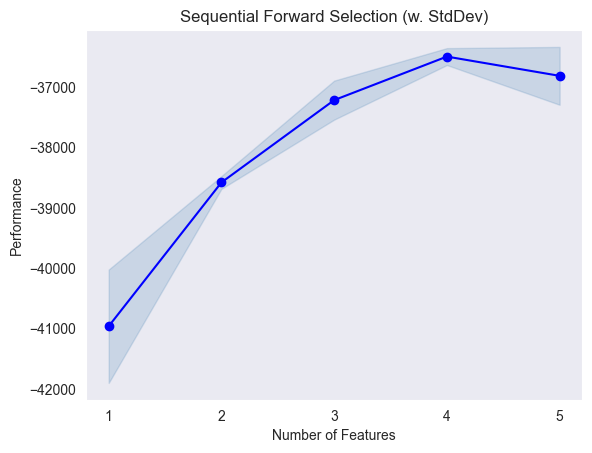

In [103]:
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs

fig = plot_sfs(sfs.get_metric_dict(), kind='std_dev')

plt.title('Sequential Forward Selection (w. StdDev)')
plt.grid()
plt.show()

In [104]:
class ColumnExtractor(object):

    def __init__(self, cols):
        self.cols = cols

    def transform(self, X):
        return X[:,self.cols]

    def fit(self, X, y=None):
        return self

In [105]:
rfe_sfs_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_sklearn),
    ('rfe_extractor', ColumnExtractor(rfe_sfs_idx)),
    ('model', regressor)
])

rfe_sfs_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['work_year',
                                                   'remote_ratio']),
                                                 ('cat',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=99999999),
                                                  ['experience_level',
                                                   'employment_type',
                                                   'job_title',
                                                   'employee_residence',
                                                   'company_location',
                                                   'company_size']),
                                                 ('quantile',
                                                  QuantileTransformer(),
                                                  ['work_year',
                                                   'remote_ratio']),
                                                 ('poly',
                                                  Pipeline(steps=[('poly',
                                                                   PolynomialFeatures()),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['work_year',
                                                   'remote_ratio']),
                                                 ('spline',
                                                  SplineTransformer(n_knots=3),
                                                  ['work_year'])])),
                ('rfe_extractor',
                 <__main__.ColumnExtractor object at 0x000001EC9FDDEE60>),
                ('model', RandomForestRegressor())])

In [106]:
predictions_sfs = rfe_sfs_pipeline.predict(X_test)

metrics = {}
metrics["mae"] = mean_absolute_error(y_test, predictions_sfs)
metrics["mape"] = mean_absolute_percentage_error(y_test, predictions_sfs)
metrics["rmse"] = root_mean_squared_error(y_test, predictions_sfs)

metrics

{'mae': 36587.70367289356,
 'mape': 0.32161494181707523,
 'rmse': 49764.85340399505}

In [107]:
experiment_id = mlflow.get_experiment_by_name(EXPERIMENT_NAME).experiment_id
RUN_NAME = 'rfe_sfs_feature_selection'

with mlflow.start_run(run_name=RUN_NAME, experiment_id=experiment_id) as run:
    # получаем уникальный идентификатор запуска эксперимента
    run_id = run.info.run_id
    mlflow.sklearn.log_model(rfe_sfs_pipeline,
                             artifact_path="models",
                             signature=signature,
                             input_example=input_example,
                             pip_requirements=req_file
                             )
    mlflow.log_metrics(metrics)
    mlflow.log_artifact('rfe_skl_cols.txt')
    mlflow.log_artifact('rfe_skl_idx.txt')
    mlflow.log_params(rfe_sfs_pipeline.get_params())

run = mlflow.get_run(run_id)
assert (run.info.status =='FINISHED')

2024/11/21 01:52:35 INFO mlflow.tracking._tracking_service.client: 🏃 View run rfe_sfs_feature_selection at: http://127.0.0.1:5000/#/experiments/1/runs/284b9211932b4f74a16b12a816b01a05.
2024/11/21 01:52:35 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1.


# Optuna

In [108]:
def objective(trial):
    # предлагаем гиперпараметры
    n_estimators = trial.suggest_int('n_estimators', 30, 50)
    max_depth = trial.suggest_int('max_depth', 2, 10)

    # создаём и обучаем модель
    opt_pipeline  = Pipeline(steps=[
        ('preprocessor', preprocessor_sklearn),
        ('rfe_extractor', ColumnExtractor(rfe_sfs_idx)),
        ('model', RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth))
    ])

    opt_pipeline.fit(X_train, y_train)

    # предсказываем и вычисляем MAE
    preds = opt_pipeline.predict(X_test)
    mae =  mean_absolute_error(y_test, preds)

    return mae

In [109]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=10)

# выводим результаты
print('Number of finished trials:', len(study.trials))
print('Best trial:', study.best_trial.params)

[I 2024-11-21 01:52:35,632] A new study created in memory with name: no-name-b0722242-59cd-45a4-977e-477090e71582
[I 2024-11-21 01:52:35,851] Trial 0 finished with value: 40896.807687181994 and parameters: {'n_estimators': 47, 'max_depth': 2}. Best is trial 0 with value: 40896.807687181994.
[I 2024-11-21 01:52:36,054] Trial 1 finished with value: 35987.646468284 and parameters: {'n_estimators': 37, 'max_depth': 8}. Best is trial 1 with value: 35987.646468284.
[I 2024-11-21 01:52:36,300] Trial 2 finished with value: 36018.76955303313 and parameters: {'n_estimators': 41, 'max_depth': 9}. Best is trial 1 with value: 35987.646468284.
[I 2024-11-21 01:52:36,488] Trial 3 finished with value: 37217.76443734748 and parameters: {'n_estimators': 37, 'max_depth': 5}. Best is trial 1 with value: 35987.646468284.
[I 2024-11-21 01:52:36,644] Trial 4 finished with value: 40894.664322828605 and parameters: {'n_estimators': 40, 'max_depth': 2}. Best is trial 1 with value: 35987.646468284.
[I 2024-11-21

Number of finished trials: 10
Best trial: {'n_estimators': 50, 'max_depth': 8}


In [110]:
opt_pipeline  = Pipeline(steps=[
    ('preprocessor', preprocessor_sklearn),
    ('rfe_extractor', ColumnExtractor(rfe_sfs_idx)),
    ('model', RandomForestRegressor(n_estimators=48, max_depth=8))
])
opt_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['work_year',
                                                   'remote_ratio']),
                                                 ('cat',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=99999999),
                                                  ['experience_level',
                                                   'employment_type',
                                                   'job_title',
                                                   'employee_residence',
                                                   'company_location',
                                                   'company_size']),
                                                 ('quantile',
                                                  QuantileTransformer(),
                                                  ['work_year',
                                                   'remote_ratio']),
                                                 ('poly',
                                                  Pipeline(steps=[('poly',
                                                                   PolynomialFeatures()),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['work_year',
                                                   'remote_ratio']),
                                                 ('spline',
                                                  SplineTransformer(n_knots=3),
                                                  ['work_year'])])),
                ('rfe_extractor',
                 <__main__.ColumnExtractor object at 0x000001EC9ED1A4D0>),
                ('model', RandomForestRegressor(max_depth=8, n_estimators=48))])

In [111]:
predictions_optuna = opt_pipeline.predict(X_test)

metrics = {}
metrics["mae"] = mean_absolute_error(y_test, predictions_optuna)
metrics["mape"] = mean_absolute_percentage_error(y_test, predictions_optuna)
metrics["rmse"] = root_mean_squared_error(y_test, predictions_optuna)

metrics

{'mae': 35853.79120109564,
 'mape': 0.3197875543518546,
 'rmse': 49120.98542991532}

In [112]:
experiment_id = mlflow.get_experiment_by_name(EXPERIMENT_NAME).experiment_id
RUN_NAME = 'rfe_sfs_feature_selection_with_optuna'

with mlflow.start_run(run_name=RUN_NAME, experiment_id=experiment_id) as run:
    # получаем уникальный идентификатор запуска эксперимента
    run_id = run.info.run_id
    mlflow.sklearn.log_model(model_sklearn,
                             artifact_path="models",
                             signature=signature,
                             input_example=input_example,
                             pip_requirements=req_file
                             )
    mlflow.log_metrics(metrics)
    mlflow.log_artifact(art)
    mlflow.log_params(opt_pipeline.get_params())

run = mlflow.get_run(run_id)
assert (run.info.status =='FINISHED')

2024/11/21 01:52:39 WARNING mlflow.models.model: Failed to validate serving input example {
  "dataframe_split": {
    "columns": [
      "work_year",
      "experience_level",
      "employment_type",
      "job_title",
      "employee_residence",
      "remote_ratio",
      "company_location",
      "company_size"
    ],
    "data": [
      [
        2022,
        "EN",
        "FT",
        "Data Analyst",
        "US",
        100,
        "US",
        "S"
      ],
      [
        2023,
        "SE",
        "FT",
        "Data Scientist",
        "US",
        0,
        "US",
        "M"
      ],
      [
        2023,
        "SE",
        "FT",
        "Data Engineer",
        "US",
        0,
        "US",
        "M"
      ],
      [
        2022,
        "SE",
        "FT",
        "Data Architect",
        "US",
        100,
        "US",
        "M"
      ],
      [
        2022,
        "SE",
        "FT",
        "Data Science Manager",
        "US",
        100,
       

# Последняя модель является лучшей -> в прод

In [113]:
opt_pipeline.fit(X, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['work_year',
                                                   'remote_ratio']),
                                                 ('cat',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=99999999),
                                                  ['experience_level',
                                                   'employment_type',
                                                   'job_title',
                                                   'employee_residence',
                                                   'company_location',
                                                   'company_size']),
                                                 ('quantile',
                                                  QuantileTransformer(),
                                                  ['work_year',
                                                   'remote_ratio']),
                                                 ('poly',
                                                  Pipeline(steps=[('poly',
                                                                   PolynomialFeatures()),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['work_year',
                                                   'remote_ratio']),
                                                 ('spline',
                                                  SplineTransformer(n_knots=3),
                                                  ['work_year'])])),
                ('rfe_extractor',
                 <__main__.ColumnExtractor object at 0x000001EC9ED1A4D0>),
                ('model', RandomForestRegressor(max_depth=8, n_estimators=48))])

In [114]:
experiment_id = mlflow.get_experiment_by_name(EXPERIMENT_NAME).experiment_id
RUN_NAME = 'rfe_sfs_feature_selection_with_optuna_full'

with mlflow.start_run(run_name=RUN_NAME, experiment_id=experiment_id) as run:
    # получаем уникальный идентификатор запуска эксперимента
    run_id = run.info.run_id
    mlflow.sklearn.log_model(model_sklearn,
                             artifact_path="models",
                             signature=signature,
                             input_example=input_example,
                             pip_requirements=req_file
                             )
    mlflow.log_artifact(art)
    mlflow.log_params(opt_pipeline.get_params())

run = mlflow.get_run(run_id)
assert (run.info.status =='FINISHED')

2024/11/21 01:52:40 WARNING mlflow.models.model: Failed to validate serving input example {
  "dataframe_split": {
    "columns": [
      "work_year",
      "experience_level",
      "employment_type",
      "job_title",
      "employee_residence",
      "remote_ratio",
      "company_location",
      "company_size"
    ],
    "data": [
      [
        2022,
        "EN",
        "FT",
        "Data Analyst",
        "US",
        100,
        "US",
        "S"
      ],
      [
        2023,
        "SE",
        "FT",
        "Data Scientist",
        "US",
        0,
        "US",
        "M"
      ],
      [
        2023,
        "SE",
        "FT",
        "Data Engineer",
        "US",
        0,
        "US",
        "M"
      ],
      [
        2022,
        "SE",
        "FT",
        "Data Architect",
        "US",
        100,
        "US",
        "M"
      ],
      [
        2022,
        "SE",
        "FT",
        "Data Science Manager",
        "US",
        100,
       